<a href="https://colab.research.google.com/github/Subham-Singh-369/OIBSIP/blob/main/DataScience-Task1-IrisFlowerClassification/Iris_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n")
df.describe()

Shape: (150, 5)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive statistics:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


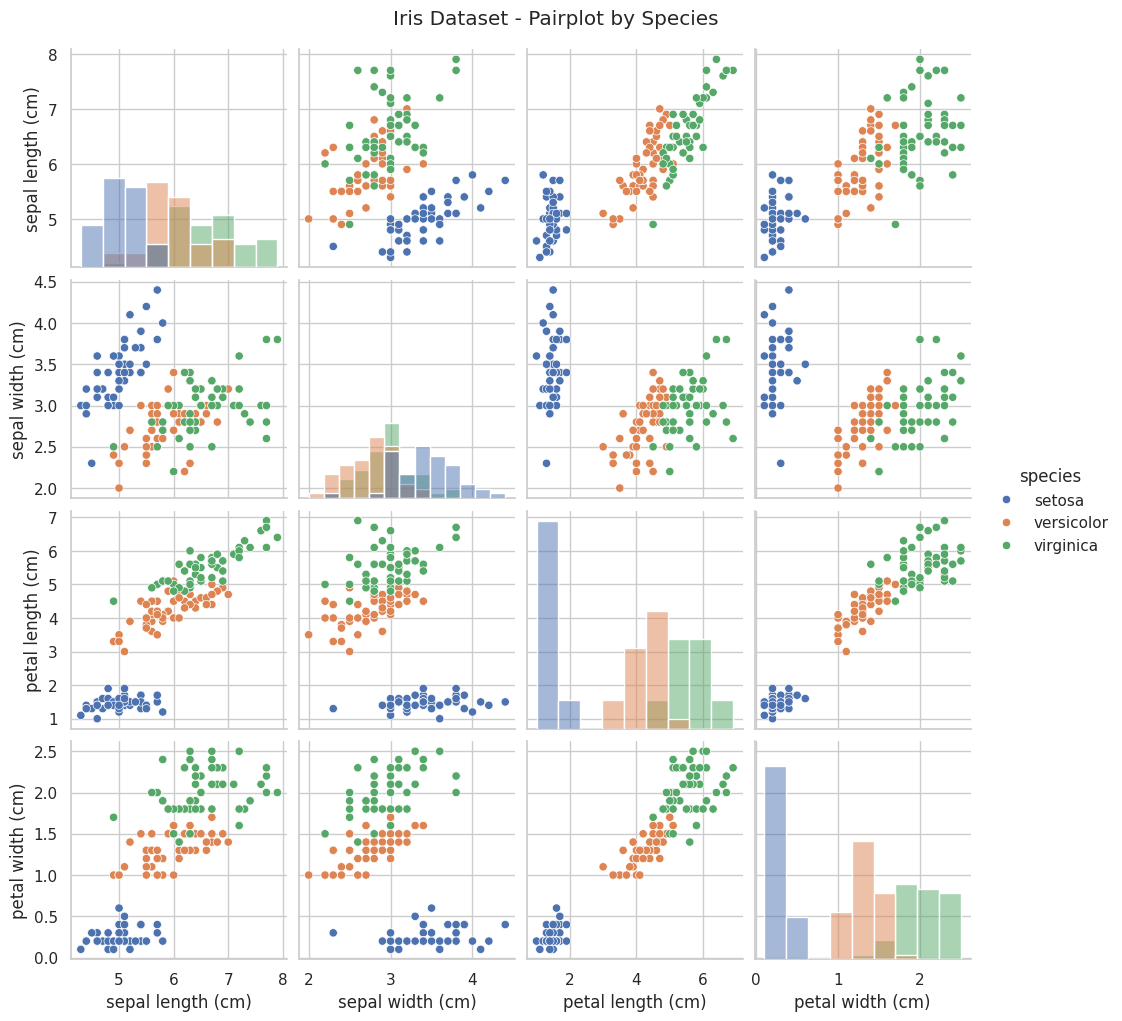

In [7]:
sns.pairplot(df, hue='species', diag_kind='hist')
plt.suptitle("Iris Dataset - Pairplot by Species", y=1.02)
plt.show()

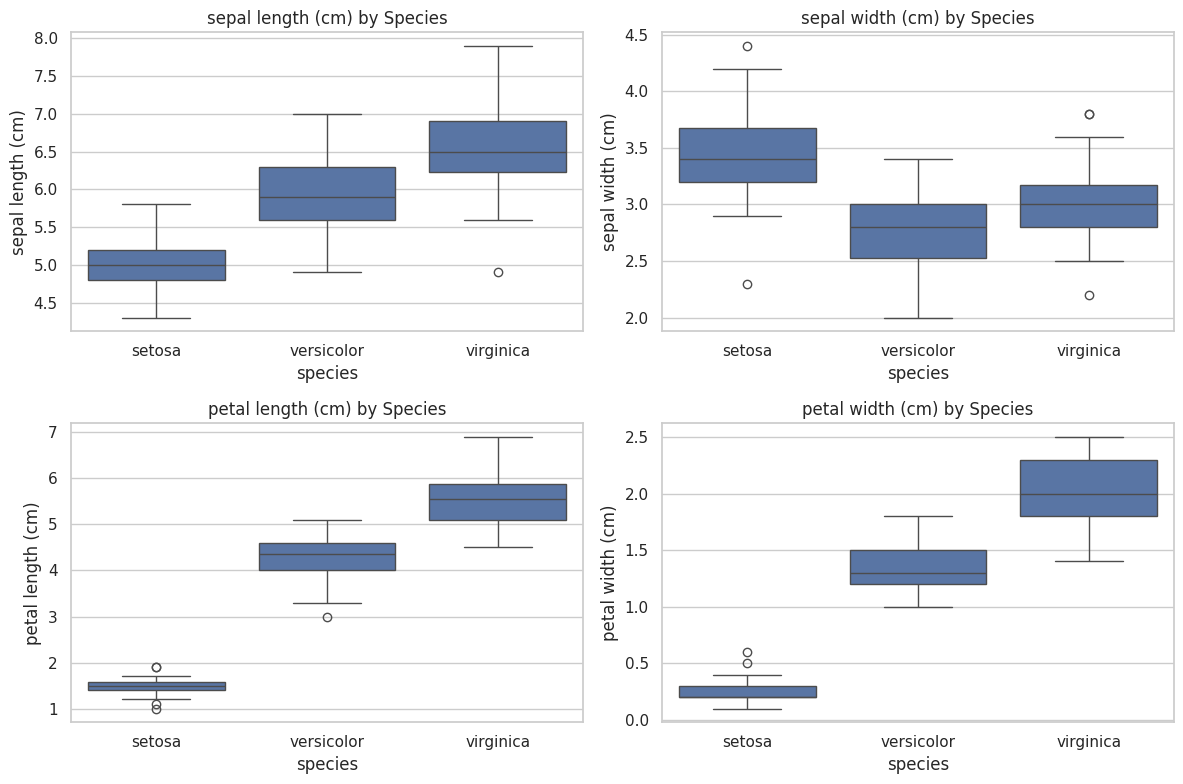

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()

## Feature Selection Discussion

From the pairplot and box plots above, **petal length** and **petal width** show
the clearest separation between the three species — setosa is easily
distinguishable from versicolor and virginica across almost every feature,
while versicolor and virginica show more overlap, particularly in sepal
measurements.

Petal measurements are the most discriminative features for this
classification task, while sepal width shows the most overlap across
species and is the least useful feature on its own.

All four features will still be used for training, since tree-based and
distance-based models can naturally down-weight less useful features,
but this insight explains *why* the models will likely perform very well.

In [9]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 120
Test set size: 30


In [10]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Model 2: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


In [11]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

=== Logistic Regression ===
Accuracy: 0.9666666666666667

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [12]:
print("=== K-Nearest Neighbors ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

=== K-Nearest Neighbors ===
Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Model Comparison & Conclusion

| Model                  | Accuracy | Notes |
|-------------------------|----------|-------|
| Logistic Regression     | 96.7%    | Misclassified 1 versicolor sample as virginica |
| K-Nearest Neighbors (k=5) | 100%   | No misclassifications on the test set |

**Best model: K-Nearest Neighbors (KNN)**

KNN achieved perfect accuracy on this test split, with no misclassifications
across all three species. This makes intuitive sense given what we saw in
the pairplot and box plots — since the species form fairly tight, well-separated
clusters in feature space (especially by petal length and petal width), a
distance-based method like KNN is naturally well-suited to this data.

Logistic Regression performed nearly as well (96.7%), with its single error
falling exactly where we expected — the slight overlap zone between
versicolor and virginica.

**Caveat:** With only 30 test samples, a single misclassification swings
accuracy by ~3.3%. On such a small dataset, both models should be considered
strong performers; KNN's perfect score shouldn't be over-interpreted as
proof it's definitively superior on unseen data — a k-fold cross-validation
would give a more robust comparison, but is beyond the scope of this task.

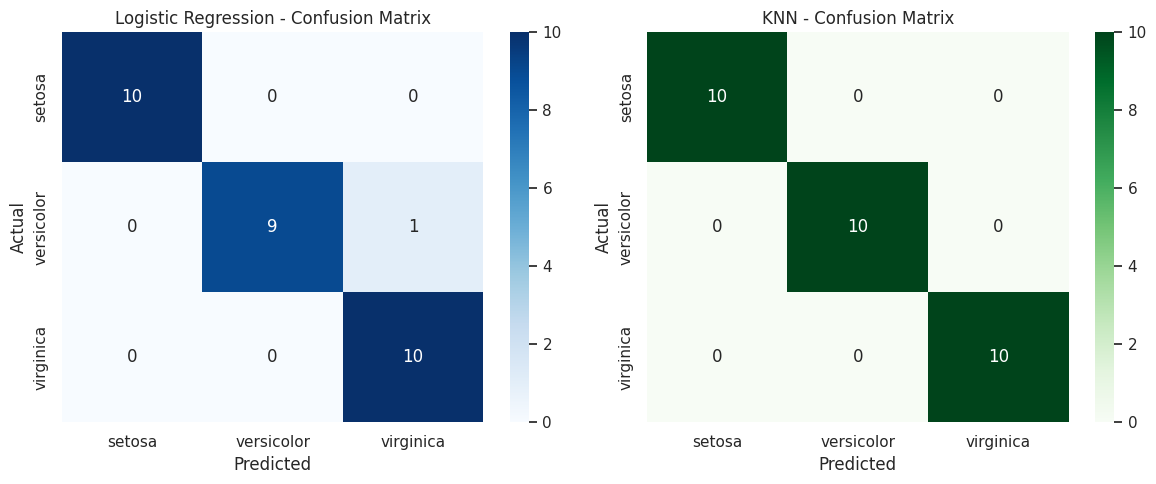

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues',
            xticklabels=log_reg.classes_, yticklabels=log_reg.classes_, ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=knn.classes_, yticklabels=knn.classes_, ax=axes[1])
axes[1].set_title('KNN - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()